# 01 · Exploratory Data Analysis (All data)

This notebook loads all exported datasets, performs basic sanity checks, adds time/session features, and surfaces foundational KPIs and visuals for the full time range.


In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 200)

from analysis.utils import load_all, add_time_features, sessionize, coverage_summary

dfs = load_all()
events = dfs['events']
embeddings = dfs['embeddings']
subpaths = dfs['subpaths']
friction = dfs['friction']

# TIMEZONE CORRECTION: Add 12 hours to correct database timestamp offset
events['ts'] = events['ts'] + pd.Timedelta(hours=12)

events = add_time_features(events)
events = sessionize(events, gap_minutes=30)
coverage_summary(dfs)


,dataset,start,end,rows
0,events,2025-10-09 17:53:22.683000+00:00,2025-10-29 18:15:44.479000+00:00,9237
1,subpaths,2025-10-10 01:15:23.354000+00:00,2025-10-14 21:28:18.774000+00:00,229
2,friction,2025-10-11 23:29:18.584000+00:00,2025-10-16 20:45:32.937000+00:00,83


In [2]:
# Basic KPIs
kpis = {
    'events_total': len(events),
    'sessions_total': events['session_id'].nunique() if 'session_id' in events.columns else None,
    'unique_domains': events['domain'].nunique() if 'domain' in events.columns else None,
    'unique_paths': events['url_path'].nunique() if 'url_path' in events.columns else None,
    'time_range': (events['ts'].min(), events['ts'].max()) if 'ts' in events.columns else None,
}
kpis


{'events_total': 9237,
 'sessions_total': 721,
 'unique_domains': 87,
 'unique_paths': 421,
 'time_range': (Timestamp('2025-10-09 17:53:22.683000+0000', tz='UTC'),
  Timestamp('2025-10-29 18:15:44.479000+0000', tz='UTC'))}

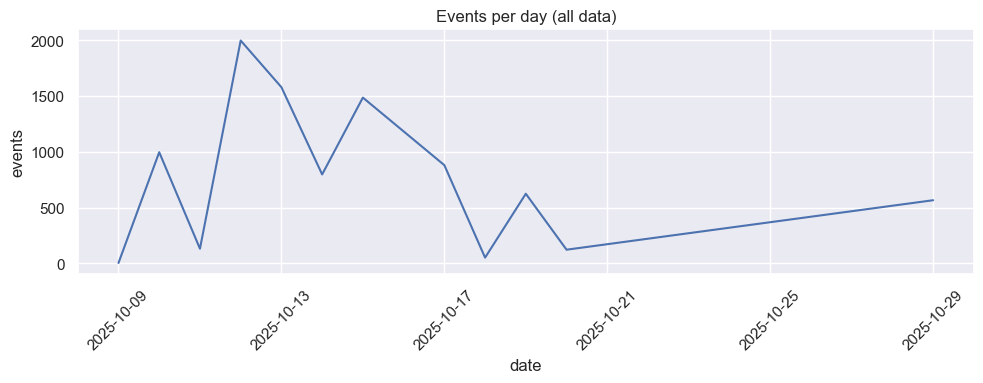

In [3]:
# Events by day
if 'date' in events.columns:
    counts = events.groupby('date').size().rename('events').reset_index()
    sns.set_theme()
    plt.figure(figsize=(10,4))
    sns.lineplot(data=counts, x='date', y='events')
    plt.title('Events per day (all data)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No date column available')


In [4]:
# Top domains and paths
_top_domains = (events['domain'].value_counts().head(15) if 'domain' in events.columns else pd.Series())
_top_paths = (events['url_path'].value_counts().head(15) if 'url_path' in events.columns else pd.Series())
_top_domains, _top_paths


(domain
 localhost:3000                                                1486
 github.com                                                    1313
 canvas.illinois.edu                                           1195
 linkedin.com                                                   904
 supabase.com                                                   511
 chatgpt.com                                                    451
 youtube.com                                                    347
 google.com                                                     302
 enterprise.com                                                 209
 observeandcreate-ogvlapqej-ommistry25s-projects.vercel.app     185
 sonatic.com                                                    160
 arc018.to                                                      128
 leen.dev                                                       108
 papercut.ics.illinois.edu                                      100
 docs.google.com                        